In [2]:
# %load_ext autoreload
# %autoreload 2

import sys
import pathlib

# Ensure the notebook can import the local src package from the project root.
project_root = pathlib.Path.cwd()
if not (project_root / 'src').exists():
    project_root = project_root.parent
sys.path.insert(0, str(project_root.resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sunpy.net import Fido, attrs as a
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.io import fits
import sunpy.map


from src.utilities import make_cube

# Dowloading AR's
 Here i going to dowload the folowing AR's witch wilson depresions were already computed with a more sofisticated method ussing hinode telescope

| NOAA | Date | θ [deg] | Spot area [Mm²] | B_av [G] | z_W,div [km] | z_W,press [km] |
| --- | --- | --- | --- | --- | --- | --- |
| 11039 | 2010.01.01 | 29 | 284 | 2471 | 659 | 366 |
| 11041 | 2010.01.26 | 20 | 170 | 2068 | 638 | 305 |
| 11106 | 2010.09.16 | 27 | 195 | 2349 | 636 | 381 |
| 11117 | 2010.10.27 | 25 | 522 | 2093 | 561 | 291 |
| 11117 | 2010.10.28 | 35 | 223 | 2090 | 625 | 313 |
| 11363 | 2011.12.06 | 25 | 1268 | 2287 | 524 | 326 |
| 11536 | 2012.07.31 | 34 | 124 | 2181 | 577 | 346 |

## Locating each AR

`a.Instrument.noaa_indices` only gives the global daily sunspot number — it has no per-region position. To get the position of a specific NOAA AR we query the **HEK** (Heliophysics Event Knowledgebase) for `AR` events filtered by `a.hek.AR.NOAANum`. Each matching record carries the region's helioprojective bounding box (`hpc_bbox`) and centroid (`hpc_x`/`hpc_y`) at that date, which we turn into a `(bottom_left, top_right)` pair for a JSOC cutout request.

`locate_ar_window` (in `src/utilities.py`) queries HEK across the *whole* `N_DAYS` window. Two things it does that are worth knowing when reading the boxes it prints:

**It filters by provider.** A single NOAA number returns rows from several `frm_name` sources describing *different objects*: `NOAA SWPC Observer` is the sunspot group (half-width ~70–140 arcsec), while `HMI SHARP` is the whole magnetic active region complex including plage (half-width ~250–400 arcsec). Sizing off a mix of the two is how NOAA 11363 previously ended up with a 736 arcsec box around a ~110 arcsec spot. We size from SWPC — the sunspot group is what the Löptien comparison is about.

**It returns a square box** sized from the *median* half-width across the window's rows, clamped to `[min_half_extent, max_half_extent]`. SWPC's reported latitude extent is degenerate (half-height 3–9 arcsec), so only the half-width carries information; a square box also keeps the ARs comparable to each other. Median rather than max because these bounding boxes are coarse and one bad row should not size the whole window.

Oversizing is not free: a large box spans a large line-of-sight solar-rotation velocity gradient, and that gradient leaks straight into any quiet-sun reference computed over the box in `02A`.

The box's **position** is anchored at the anchor day only — `n_days` does not move it. Per-frame positioning is left entirely to `a.jsoc.Cutout(tracking=True)`, which rigidly rotates the box forward from the anchor coordinate's `obstime` (sunpy passes it as JSOC's `t_ref`). Note that sunspots rotate slightly *faster* than that tracking rate, so residual drift accumulates with `N_DAYS` — fine at 2–3 days, worth re-checking beyond that, since the only slack is `locate_ar_window`'s `padding`.

In [3]:
# for now just dowloading 11536 and do tests with it

active_regions = [
    #{'noaa': 11039, 'date': '2010-01-01'},
    #{'noaa': 11041, 'date': '2010-01-26'},
    {'noaa': 11106, 'date': '2010-09-16'},
    # 11117's two catalog dates (2010-10-27, 2010-10-28) are one continuous AR passage —
    # a multi-day window anchored at the earlier date already covers the later one, so
    # they're merged into a single entry instead of being processed twice.
    {'noaa': 11117, 'date': '2010-10-27'},
    {'noaa': 11363, 'date': '2011-12-06'},
    {'noaa': 11536, 'date': '2012-07-31'},
]

In [4]:
from src.utilities import locate_ar_window

N_DAYS = 4  # minimum continuous days of data to fetch per AR

# Per-AR overrides for the box geometry — keyword arguments forwarded straight to
# locate_ar_window. Comment an entry out to turn that override off. (This lives here rather
# than beside series_override/sample_override further down only because it has to be defined
# before the loop that uses it.)
#
# 11536: SWPC under-reports this group badly. Measured from the frames already on disk, it
# grows from 165" to 220" across and sits ~35" left of the reported centroid, so the default
# median sizing (200" square) clips it on the left in *every* frame. 'max' alone (244")
# still leaves ~0" margin at the start, so the padding goes up too.
box_override = {
    11536: {'statistic': 'max', 'padding': 60 * u.arcsec},   # -> 304" square
}

for ar in active_regions:
    ar['bl'], ar['tr'], ar['time_start'], ar['time_end'] = locate_ar_window(
        ar['noaa'], ar['date'], n_days=N_DAYS, **box_override.get(ar['noaa'], {}))
    print(f"NOAA {ar['noaa']} ({ar['date']}): window {ar['time_start']} .. {ar['time_end']}  "
          f"bl={ar['bl'].Tx:.1f},{ar['bl'].Ty:.1f}  tr={ar['tr'].Tx:.1f},{ar['tr'].Ty:.1f}")

NOAA 11106: box 329 arcsec square, centered -278 arcsec,-432 arcsec — from 4 NOAA SWPC Observer row(s), median half-width 134 arcsec
NOAA 11106 (2010-09-16): window 2010-09-16 00:00:00 .. 2010-09-19 23:59:59  bl=-442.7 arcsec,-596.8 arcsec  tr=-113.8 arcsec,-267.9 arcsec
NOAA 11117: box 202 arcsec square, centered 234 arcsec,272 arcsec — from 4 NOAA SWPC Observer row(s), median half-width 71 arcsec
NOAA 11117 (2010-10-27): window 2010-10-27 00:00:00 .. 2010-10-30 23:59:59  bl=133.2 arcsec,170.6 arcsec  tr=335.4 arcsec,372.9 arcsec
NOAA 11363: box 220 arcsec square, centered 143 arcsec,-355 arcsec — from 4 NOAA SWPC Observer row(s), median half-width 80 arcsec
NOAA 11363 (2011-12-06): window 2011-12-06 00:00:00 .. 2011-12-09 23:59:59  bl=32.6 arcsec,-465.6 arcsec  tr=253.1 arcsec,-245.1 arcsec
NOAA 11536: box 315 arcsec square, centered -383 arcsec,-447 arcsec — from 4 NOAA SWPC Observer row(s), max half-width 98 arcsec
NOAA 11536 (2012-07-31): window 2012-07-31 00:00:00 .. 2012-08-03 2

## Downloading tracked cutouts from JSOC

With each AR's `(bottom_left, top_right)` box and full `time_start`/`time_end` window in hand, we reuse `src/scripts.py`'s `download_regions`/`make_cubes` — the same helpers already used for the DS9-defined regions — but driven by the HEK-derived boxes instead. `a.jsoc.Cutout(..., tracking=True)` makes JSOC do the cropping and solar-rotation tracking server-side, so we only ever download the small cutout, not the full 4096x4096 disk.

Each AR gets its own `data/raw/NOAA_<number>_<date>/region_01/` directory.

**Resuming.** `download_regions` checks the timestamps already on disk for a region/series and only requests the missing tail of the window, so re-running after an interrupted download won't duplicate files or waste JSOC export requests. Two limits to keep in mind:

- It assumes existing files are contiguous from the start of the range — there is no gap detection or backfill.
- It does **not** check that the files on disk were fetched with the *same box*. If you change `N_DAYS`, the padding, or anything else that resizes the box, delete the region directory rather than resuming — otherwise the cube ends up with frames of two different geometries, which `make_cube` will warn about but cannot properly repair.

**Partial failures.** Individual files fail fairly often. `download_regions` now retries them once and reports `status: 'partial'` with the URLs still missing, instead of reporting success with a short file list. Take `partial` as seriously as `failed`: a frame missing from the *middle* of the window doesn't just shorten that series, it knocks it out of step with the other two from that point on. (`02A` defends against this by joining on timestamps, but the missing frames are still gone.)

**Note:** HMI science data only starts ~2010-05-01, so AR 11039 (2010-01-01) and AR 11041 (2010-01-26) predate it. They're dropped up front in the `locate_ar_window` cell above.

**Data volume:** NOAA 11117 is forced onto `hmi.*_45s` for its *entire* `N_DAYS`-day window (see `series_override` below) because JSOC's `hmi.*_720s` series 500-errors for any query touching 2010-10-26..29 — a JSOC-side gap, not our bug. Native 45s cadence over multiple days is an order of magnitude more data than everyone else's 720s. To keep that in check, `sample_override` applies `a.Sample(360*u.s)` for 11117 — JSOC downsamples **server-side**, so we only ever download every 8th 45s frame (≈360s cadence), roughly matching the other ARs' 720s data volume instead of dwarfing it.

In [ ]:
from src.scripts import download_regions, make_cubes

notify_email = 'thomas.quamtum@gmail.com'  # must be a JSOC-registered export email
series_list  = ['hmi.Ic_720s', 'hmi.V_720s', 'hmi.M_720s']

# NOAA 11117's 720s data is broken, so we have to fetch the 45s series instead with the 720s cadence
series_override = {
    11117: ['hmi.Ic_45s', 'hmi.V_45s', 'hmi.M_45s'],
}
sample_override = {
    11117: 720 * u.s,
}

In [14]:
all_summaries = []

# Dowloads

## 11106

In [15]:
ar = active_regions[0]
print(ar['noaa'])

region_base = pathlib.Path('../data/raw') / f"NOAA_{ar['noaa']}_{ar['date']}"
regions_hpc = [(ar['bl'], ar['tr'])]
ar_series   = series_override.get(ar['noaa'], series_list)
ar_sample   = sample_override.get(ar['noaa'])


for series in ar_series:
    summary = download_regions(regions_hpc, region_base, ar['time_start'], ar['time_end'],
                                notify_email, series, sample=ar_sample)
    all_summaries.append((ar['noaa'], ar['date'], series, summary))

11106
Region 01 [hmi.Ic_720s]: already covers requested range through 2010-09-20 00:00:00 — skipping
Region 01 [hmi.V_720s]: 120 new frames found (resuming)


2026-08-09 22:10:33 - drms - INFO: Export request pending. [id=JSOC_20260810_000947, status=2]
2026-08-09 22:10:33 - drms - INFO: Waiting for 5 seconds...
2026-08-09 22:10:42 - drms - INFO: Export request pending. [id=JSOC_20260810_000947, status=1]
2026-08-09 22:10:42 - drms - INFO: Waiting for 10 seconds...
2026-08-09 22:10:53 - drms - INFO: Export request pending. [id=JSOC_20260810_000947, status=1]
2026-08-09 22:10:53 - drms - INFO: Waiting for 10 seconds...
2026-08-09 22:11:03 - drms - INFO: Export request pending. [id=JSOC_20260810_000947, status=1]
2026-08-09 22:11:03 - drms - INFO: Waiting for 10 seconds...
2026-08-09 22:11:14 - drms - INFO: Export request pending. [id=JSOC_20260810_000947, status=1]
2026-08-09 22:11:14 - drms - INFO: Waiting for 10 seconds...
2026-08-09 22:11:24 - drms - INFO: Export request pending. [id=JSOC_20260810_000947, status=1]
2026-08-09 22:11:24 - drms - INFO: Waiting for 10 seconds...
2026-08-09 22:11:36 - drms - INFO: Export request pending. [id=JS

INFO: 112 URLs found for download. Full request totaling 66MB [sunpy.net.jsoc.jsoc]


Files Downloaded:   0%|          | 0/112 [00:00<?, ?file/s]

hmi.v_720s.20100919_001200_TAI.1.Dopplergram.fits:   0%|          | 0.00/611k [00:00<?, ?B/s]

...

hmi.m_720s.20100919_232400_TAI.1.magnetogram.fits:   0%|          | 0.00/501k [00:00<?, ?B/s]

hmi.m_720s.20100919_233600_TAI.1.magnetogram.fits:   0%|          | 0.00/501k [00:00<?, ?B/s]

hmi.m_720s.20100919_234800_TAI.1.magnetogram.fits:   0%|          | 0.00/501k [00:00<?, ?B/s]

hmi.m_720s.20100920_000000_TAI.1.magnetogram.fits:   0%|          | 0.00/501k [00:00<?, ?B/s]

  -> 112 files saved to ../data/raw/NOAA_11106_2010-09-16/region_01


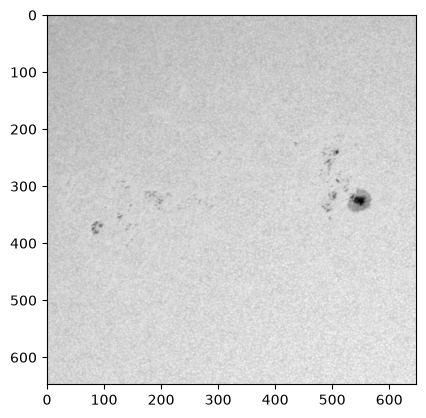

In [20]:
file_list = sorted(region_base.glob('region_01/*.continuum.fits'))

with fits.open(file_list[0]) as hdu:
    data_shape = hdu[1].data.shape
    header = hdu[1].header.copy()

plt.imshow(hdu[1].data, cmap='gray')
plt.show()

## 11117

In [21]:
ar = active_regions[1]
print(ar['noaa'])

region_base = pathlib.Path('../data/raw') / f"NOAA_{ar['noaa']}_{ar['date']}"
regions_hpc = [(ar['bl'], ar['tr'])]
ar_series   = series_override.get(ar['noaa'], series_list)
ar_sample   = sample_override.get(ar['noaa'])


for series in ar_series:
    summary = download_regions(regions_hpc, region_base, ar['time_start'], ar['time_end'],
                                notify_email, series, sample=ar_sample)
    all_summaries.append((ar['noaa'], ar['date'], series, summary))

11117
Region 01 [hmi.Ic_45s]: 119 new frames found (resuming)


2026-08-09 22:22:07 - drms - INFO: Export request pending. [id=JSOC_20260810_001003, status=2]
2026-08-09 22:22:07 - drms - INFO: Waiting for 5 seconds...
2026-08-09 22:22:16 - drms - INFO: Export request pending. [id=JSOC_20260810_001003, status=1]
2026-08-09 22:22:16 - drms - INFO: Waiting for 10 seconds...
2026-08-09 22:22:27 - drms - INFO: Export request pending. [id=JSOC_20260810_001003, status=1]
2026-08-09 22:22:27 - drms - INFO: Waiting for 10 seconds...
2026-08-09 22:22:37 - drms - INFO: Export request pending. [id=JSOC_20260810_001003, status=1]
2026-08-09 22:22:37 - drms - INFO: Waiting for 10 seconds...
2026-08-09 22:22:47 - drms - INFO: Export request pending. [id=JSOC_20260810_001003, status=1]
2026-08-09 22:22:47 - drms - INFO: Waiting for 10 seconds...
2026-08-09 22:23:00 - drms - INFO: Export request pending. [id=JSOC_20260810_001003, status=1]
2026-08-09 22:23:00 - drms - INFO: Waiting for 10 seconds...
2026-08-09 22:23:12 - drms - INFO: Export request pending. [id=JS

INFO: 119 URLs found for download. Full request totaling 26MB [sunpy.net.jsoc.jsoc]


Files Downloaded:   0%|          | 0/119 [00:00<?, ?file/s]

hmi.ic_45s.20101030_001330_TAI.2.continuum.fits:   0%|          | 0.00/236k [00:00<?, ?B/s]

...

hmi.m_45s.20101030_134330_TAI.2.magnetogram.fits:   0%|          | 0.00/222k [00:00<?, ?B/s]

hmi.m_45s.20101030_023130_TAI.2.magnetogram.fits:   0%|          | 0.00/219k [00:00<?, ?B/s]

hmi.m_45s.20101028_081930_TAI.2.magnetogram.fits:   0%|          | 0.00/225k [00:00<?, ?B/s]

2026-08-09 22:40:24 - parfive - INFO: http://jsoc.stanford.edu/SUM38/D2025609781/S00000/hmi.m_45s.20101028_081930_TAI.2.magnetogram.fits failed to download with exception
Cannot connect to host jsoc.stanford.edu:80 ssl:default [Connect call failed ('171.64.103.244', 80)]
2026-08-09 22:40:24 - parfive - INFO: http://jsoc.stanford.edu/SUM38/D2025609781/S00000/hmi.m_45s.20101030_023130_TAI.2.magnetogram.fits failed to download with exception
Cannot connect to host jsoc.stanford.edu:80 ssl:default [Connect call failed ('171.64.103.244', 80)]


2/0 files failed to download. Please check `.errors` for details
  -> 440 files saved to ../data/raw/NOAA_11117_2010-10-27/region_01
  PARTIAL: 2 file(s) still missing after retry


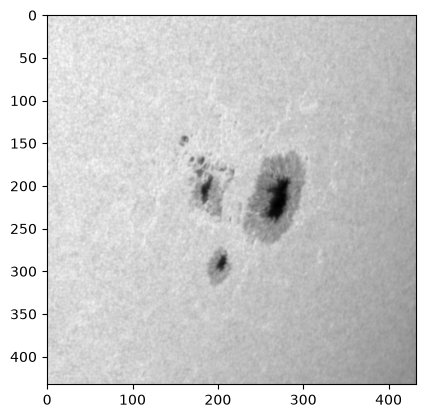

In [30]:
file_list = sorted(region_base.glob('region_01/*.continuum.fits'))

with fits.open(file_list[700]) as hdu:
    data_shape = hdu[1].data.shape
    header = hdu[1].header.copy()

plt.imshow(hdu[1].data, cmap='gray')
plt.show()

## 11363

In [ ]:
ar = active_regions[2]
print(ar['noaa'])

region_base = pathlib.Path('../data/raw') / f"NOAA_{ar['noaa']}_{ar['date']}"
regions_hpc = [(ar['bl'], ar['tr'])]
ar_series   = series_override.get(ar['noaa'], series_list)
ar_sample   = sample_override.get(ar['noaa'])


for series in ar_series:
    summary = download_regions(regions_hpc, region_base, ar['time_start'], ar['time_end'],
                                notify_email, series, sample=ar_sample)
    all_summaries.append((ar['noaa'], ar['date'], series, summary))

11363
Region 01 [hmi.Ic_720s]: 481 new frames found


2026-08-09 22:46:58 - drms - INFO: Export request pending. [id=JSOC_20260809_005379, status=2]
2026-08-09 22:46:58 - drms - INFO: Waiting for 5 seconds...
2026-08-09 22:47:04 - drms - INFO: Export request finished. [id=JSOC_20260809_005379, status=0]
2026-08-09 22:47:04 - sunpy - INFO: 479 URLs found for download. Full request totaling 125MB


INFO: 479 URLs found for download. Full request totaling 125MB [sunpy.net.jsoc.jsoc]


Files Downloaded:   0%|          | 0/479 [00:00<?, ?file/s]

hmi.ic_720s.20111206_000000_TAI.1.continuum.fits:   0%|          | 0.00/282k [00:00<?, ?B/s]

...

hmi.m_720s.20111207_001200_TAI.1.magnetogram.fits:   0%|          | 0.00/251k [00:00<?, ?B/s]

hmi.m_720s.20111207_002400_TAI.1.magnetogram.fits:   0%|          | 0.00/251k [00:00<?, ?B/s]

hmi.m_720s.20111207_003600_TAI.1.magnetogram.fits:   0%|          | 0.00/251k [00:00<?, ?B/s]

hmi.m_720s.20111207_004800_TAI.1.magnetogram.fits:   0%|          | 0.00/251k [00:00<?, ?B/s]

hmi.m_720s.20111207_010000_TAI.1.magnetogram.fits:   0%|          | 0.00/251k [00:00<?, ?B/s]

----


In [ ]:


all_summaries = []  # (noaa, date, series, summary) for the consolidated report below

for ar in active_regions:
    region_base = pathlib.Path('../data/raw') / f"NOAA_{ar['noaa']}_{ar['date']}"
    regions_hpc = [(ar['bl'], ar['tr'])]
    ar_series   = series_override.get(ar['noaa'], series_list)
    ar_sample   = sample_override.get(ar['noaa'])

    if dry_run:
        print(f"[dry run] NOAA {ar['noaa']} ({ar['date']}) -> {region_base} "
              f"({ar['time_start']} .. {ar['time_end']}, {ar_series}, sample={ar_sample})")
        continue

    for series in ar_series:
        summary = download_regions(regions_hpc, region_base, ar['time_start'], ar['time_end'],
                                    notify_email, series, sample=ar_sample)
        all_summaries.append((ar['noaa'], ar['date'], series, summary))

# Consolidated report — useful after a long multi-AR, multi-day run.
# 'partial' matters as much as 'failed': a missing *mid-window* frame is not a smaller
# dataset, it knocks that series out of step with the other two from that point on.
# Re-run this cell to resume; only clear the region and start over if the box changed.
by_status = {}
for noaa, date, series, summary in all_summaries:
    for region, info in summary.items():
        by_status.setdefault(info['status'], []).append((noaa, date, series, region, info))

for status in ('failed', 'partial'):
    entries = by_status.get(status, [])
    if entries:
        print(f"\n{status.upper()} downloads:")
        for noaa, date, series, region, info in entries:
            detail = info.get('error') or f"{len(info.get('failed_urls', []))} file(s) missing"
            print(f"  NOAA {noaa} ({date}) region_{region:02d} [{series}]: {detail}")

if all_summaries and not (by_status.get('failed') or by_status.get('partial')):
    print(f"\nAll {len(all_summaries)} region/series downloads complete, no missing files.")

Region 01 [hmi.Ic_720s]: already covers requested range through 2010-09-19 00:00:00 — skipping
Region 01 [hmi.V_720s]: already covers requested range through 2010-09-19 00:00:00 — skipping
Region 01 [hmi.M_720s]: already covers requested range through 2010-09-19 00:00:00 — skipping
Region 01 [hmi.Ic_45s]: already covers requested range through 2010-10-30 00:00:45 — skipping
Region 01 [hmi.V_45s]: 721 new frames found


2026-08-09 21:43:15 - drms - INFO: Export request pending. [id=JSOC_20260809_005046, status=2]
2026-08-09 21:43:15 - drms - INFO: Waiting for 5 seconds...
2026-08-09 21:43:20 - drms - INFO: Export request finished. [id=JSOC_20260809_005046, status=0]
2026-08-09 21:43:20 - sunpy - INFO: 710 URLs found for download. Full request totaling 193MB


INFO: 710 URLs found for download. Full request totaling 193MB [sunpy.net.jsoc.jsoc]


Files Downloaded:   0%|          | 0/710 [00:00<?, ?file/s]

hmi.v_45s.20101027_000045_TAI.2.Dopplergram.fits:   0%|          | 0.00/276k [00:00<?, ?B/s]

...

2026-08-09 21:59:39 - parfive - INFO: http://jsoc.stanford.edu/SUM2/D2025591369/S00000/hmi.m_45s.20101027_061845_TAI.2.magnetogram.fits failed to download with exception



1/0 files failed to download. Please check `.errors` for details
  1 file(s) failed — retrying


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

hmi.m_45s.20101027_061845_TAI.2.magnetogram.fits:   0%|          | 0.00/253k [00:00<?, ?B/s]

  -> 64 files saved to ../data/raw/NOAA_11117_2010-10-27/region_01
Region 01 [hmi.Ic_720s]: 361 new frames found


In [ ]:
if True:
    for ar in active_regions:
        region_base = pathlib.Path('../data/raw') / f"NOAA_{ar['noaa']}_{ar['date']}"
        regions_hpc = [(ar['bl'], ar['tr'])]
        for series in series_override.get(ar['noaa'], series_list):
            make_cubes(regions_hpc, region_base, series)

KeyboardInterrupt: 